In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

fig_save_path = "/Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/AR_plots_new/"

In [2]:
cd ..

/Users/thomassainsbury/Documents/Mathis_lab/Mathis_lab_code/FreelyMovingVR4Mice/dj_pipeline


In [3]:
%run env.py
%run run.py connect

2024-08-22 11:18:23,062::INFO::settings.py::Setting loglevel to INFO
2024-08-22 11:18:23,063::INFO::settings.py::Setting stores to {}
2024-08-22 11:18:23,063::INFO::settings.py::Setting database.misc.schema_prefix to 
2024-08-22 11:18:23,063::INFO::settings.py::Setting database.misc.create_tables to True
2024-08-22 11:18:23,064::INFO::settings.py::Setting enable_python_native_blobs to True
2024-08-22 11:18:23,064::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2024-08-22 11:18:23,064::INFO::settings.py::Setting database.user to thomas
2024-08-22 11:18:23,065::INFO::settings.py::Setting database.password to thomas


Connecting thomas@128.178.51.167:3309


2024-08-22 11:18:23,274::INFO::connection.py::Connected thomas@128.178.51.167:3309
2024-08-22 11:18:23,347::INFO::table.py::could not log event in table ~log
2024-08-22 11:18:23,733::INFO::table.py::could not log event in table ~log


In [46]:
from vr4mice.schema import vr4mice, dlc, base_analysis
import vr4mice.analysis.plotting as plotting
import vr4mice.analysis.utils as utils
import vr4mice.analysis.visual_discrim_functions as vdf
vdf.get_rc_params()

In [47]:
base_analysis.DataFrame().fetch("dataset")

array(['Jacana_2024-07-26_1', 'Jacana_2024-07-27_1',
       'Lemming_2024-07-26_1', 'Lemming_2024-07-27_1',
       'Lemming_2024-07-28_1', 'Lemming_2024-07-29_2',
       'Lemming_2024-07-30_1', 'Lemming_2024-07-31_1',
       'Lemming_2024-08-01_1', 'Lemming_2024-08-05_1',
       'Lemming_2024-08-06_3', 'Lemming_2024-08-07_1',
       'Lemming_2024-08-08_1', 'Lemming_2024-08-09_1',
       'Lemming_2024-08-09_2', 'Lemming_2024-08-10_1',
       'Lemming_2024-08-11_1', 'Lemming_2024-08-12_1',
       'Lemming_2024-08-13_1', 'Lemming_2024-08-14_1',
       'Lemming_2024-08-15_1', 'Lemming_2024-08-16_1',
       'Nightingale_2024-07-27_1', 'Nightingale_2024-07-28_1',
       'Nightingale_2024-07-29_2', 'Nightingale_2024-07-30_1',
       'Nightingale_2024-07-31_2', 'Nightingale_2024-08-01_1',
       'Nightingale_2024-08-02_1', 'Nightingale_2024-08-06_1',
       'Nightingale_2024-08-07_1', 'Nightingale_2024-08-08_2',
       'Nightingale_2024-08-09_2', 'Nightingale_2024-08-10_1',
       'Nightingale

In [6]:
training_p1 = [
               {"dataset": "Nightingale_2024-07-27_1"},
               {"dataset": "Nightingale_2024-07-28_1"},
               {"dataset": "Nightingale_2024-07-29_2"},
               {"dataset": "Nightingale_2024-07-30_1"},
               {"dataset": "Nightingale_2024-07-31_2"},
               {"dataset": "Nightingale_2024-08-01_1"},
               {"dataset": "Lemming_2024-07-27_1"},
               {"dataset": "Lemming_2024-07-28_1"},
               {"dataset": "Lemming_2024-07-29_2"},
               {"dataset": "Lemming_2024-07-30_1"},
               {"dataset": "Lemming_2024-08-01_1"},
              ]

training_p2 = [
               {"dataset": "Nightingale_2024-08-02_1"},
               {"dataset": "Nightingale_2024-08-06_1"},
               {"dataset": "Lemming_2024-08-05_1"}
              ]

training_p3 = [
               {"dataset": "Nightingale_2024-08-07_1"},
               {"dataset": "Nightingale_2024-08-08_2"},
               {"dataset": "Nightingale_2024-08-09_2"},
               {"dataset": "Lemming_2024-08-06_3"},
               {"dataset": "Lemming_2024-08-07_1"},
               {"dataset": "Lemming_2024-08-08_1"},
              ]

In [7]:
def get_all_in_list(data_set_list, training_stage="detection_without_velo"):
    print(training_stage)
    big_df = []
    day = 0
    for d in data_set_list:
        
        split_d = d["dataset"].split("_")
        print(split_d)
        df, box_df = base_analysis.DataFrame().get_data(key =  d)
        df ["mouse_name"] = split_d [0]
        df ["session"] = df ["dataset"]
        df ["date"] = split_d [1]
        df ["training_stage"] = training_stage
        big_df.append(df)
    data =  pd.concat(big_df).reset_index()
    return pd.concat(big_df).reset_index(), box_df


In [8]:
def get_training_data(training_p1 = training_p1, training_p2=training_p2, training_p3=training_p3):
    df_1, box_df = get_all_in_list(data_set_list=training_p1)
    df_2, box_df = get_all_in_list(data_set_list=training_p2, training_stage="detection_with_velo")
    df_3, box_df = get_all_in_list(data_set_list=training_p3, training_stage="discrimination_no_occluders")
    big_df = pd.concat([df_1, df_2,df_3])
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)
    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max())
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)

    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max()
    )
    big_df["velocity"][big_df ["velocity"] > 300] = np.nan
    big_df["veloctiy"] =big_df["velocity"].interpolate().copy()
    return(big_df.reset_index(drop=True))

In [33]:
def training_plots(big_df, mouse_name, variable,  ax, legend=False, ylim = (0,1), midpoint_line = True, 
                  criterion_line=True, ylabel="Success rate/session", xlabel= "Session", cmap = ["#3FB47C","#1F6F49", "#FF1493"],s=100):
    
    big_df = big_df.copy()
    mean_mouse = big_df.groupby(["mouse_name", "date", "training_stage", "dataset", "trial"],as_index=False).mean(numeric_only=True)
    mean_mouse = mean_mouse.groupby(["mouse_name", "date", "training_stage", "dataset"],as_index=False).mean(numeric_only=True)
    mean_mouse ["date"] = pd.to_datetime(mean_mouse.date)
    data = mean_mouse[mean_mouse.mouse_name == mouse_name].copy()
    data ["session_increment"] = np.arange(data.shape[0])
    sns.lineplot(data = data, x="session_increment",y= variable, color="black", legend=None, alpha=0.5, ax=ax)
    sns.scatterplot(data = data, x="session_increment",y= variable, hue="training_stage", palette=cmap, alpha=0.9,legend=None, zorder=100,s=s, ax=ax)
    
    ax.set_ylim(ylim [0],ylim[1])
    if midpoint_line ==True:
        ax.axhline(0.5, linestyle="dashed", color="black", alpha=0.5)
    if criterion_line == True:
        ax.axhline(0.70, linestyle="dashed", color="red", alpha=0.3)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    sns.despine(offset=10)

In [36]:
big_df = get_training_data()

detection_without_velo
['Nightingale', '2024-07-27', '1']
['Nightingale', '2024-07-28', '1']
['Nightingale', '2024-07-29', '2']
['Nightingale', '2024-07-30', '1']
['Nightingale', '2024-07-31', '2']
['Nightingale', '2024-08-01', '1']
['Lemming', '2024-07-27', '1']
['Lemming', '2024-07-28', '1']
['Lemming', '2024-07-29', '2']
['Lemming', '2024-07-30', '1']
['Lemming', '2024-08-01', '1']
detection_with_velo
['Nightingale', '2024-08-02', '1']
['Nightingale', '2024-08-06', '1']
['Lemming', '2024-08-05', '1']
discrimination_no_occluders
['Nightingale', '2024-08-07', '1']
['Nightingale', '2024-08-08', '2']
['Nightingale', '2024-08-09', '2']
['Lemming', '2024-08-06', '3']
['Lemming', '2024-08-07', '1']
['Lemming', '2024-08-08', '1']


/var/folders/xx/w02j3bzd5n549z3dmcg59ddw0000gn/T/ipykernel_26828/1832212506.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  big_df["velocity"][big_df ["velocity"] > 300] = np.nan


In [11]:
big_df = big_df.reset_index(drop=True)

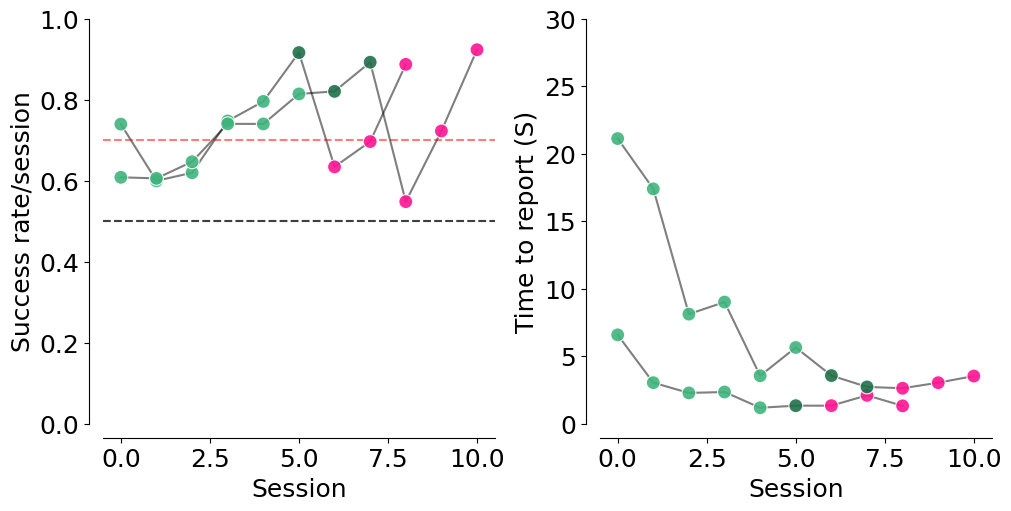

In [35]:
fig, ax = plt.subplots(1,2,figsize=(10,5), constrained_layout=True)

training_plots(big_df, mouse_name="Lemming", variable = "trial_rewarded", ax=ax[0])
training_plots(big_df, mouse_name="Nightingale", variable = "trial_rewarded", ax=ax[0])

training_plots(big_df, mouse_name="Lemming", variable = "trial_duration", criterion_line=False, midpoint_line=False, ax=ax[1])
training_plots(big_df, mouse_name="Nightingale", variable = "trial_duration", ylim = (0,30)
             ,ylabel = "Time to report (S)", criterion_line=False, midpoint_line=False,ax=ax[1])
plt.savefig(fig_save_path + "training_plots_cross_animal.svg", transparent=True)


In [ ]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
training_plot(big_df, mouse_name="Lemming", variable = "trial_duration", criterion_line=False, midpoint_line=False, ax=ax)
training_plot(big_df, mouse_name="Nightingale", variable = "trial_duration", ylim = (0,30)
             ,ylabel = "Time to report (S)", criterion_line=False, midpoint_line=False,ax=ax)

In [ ]:
training_plot(big_df, mouse_name="Lemming", variable = "trial_right_choice", criterion_line=False, midpoint_line=False)
training_plot(big_df, mouse_name="Nightingale", variable = "trial_right_choice", ylim = (0,1)
             ,ylabel = "p(right choice)", criterion_line=False, midpoint_line=True)


In [ ]:
def calculate_angular_velocity(angles, time_intervals):
    """
    Calculate the angular velocity from a series of angles (in degrees) and time intervals.

    Parameters:
    - angles: A list or array of angles in degrees.
    - time_intervals: A list or array of time intervals between each measurement.

    Returns:
    - angular_velocities: A list of angular velocities between each timepoint.
    """
    # Convert angles to radians
    angles_rad = np.deg2rad(angles)

    # Calculate the cosine and sine of the angles
    cos_vals = np.cos(angles_rad)
    sin_vals = np.sin(angles_rad)

    # Calculate the differences in cos and sin components
    delta_cos = np.diff(cos_vals)
    delta_sin = np.diff(sin_vals)

    # Calculate the angular difference using atan2
    delta_theta = np.arctan2(delta_sin, delta_cos)

    # Ensure the angular differences are in the range -pi to pi
    delta_theta = np.mod(delta_theta + np.pi, 2 * np.pi) - np.pi

    # Calculate the angular velocity
    angular_velocities = delta_theta / time_intervals

    return angular_velocities

In [ ]:
calculate_angular_velocity(big_df.head_dir, np.diff(big_df.time,0))

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
data = [np.random.normal(0,3,10), np.random.normal(2,1,10)]

In [ ]:
ttest_ind(data[0], data[1])

In [ ]:
plt.hist(data[0], bins= np.linspace(-20,20,20), density=True)
plt.hist(data[1], bins= np.linspace(-20,20,20),density=True)